In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)

In [16]:
from ipywidgets import FileUpload
import io

upload = FileUpload(accept='.csv', multiple=False)
display(upload)

FileUpload(value=(), accept='.csv', description='Upload')

In [18]:
df = pd.read_csv(io.BytesIO(upload.value[0].content))
df.shape

(1470, 35)

In [19]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [21]:
df.isnull().sum().sum()

np.int64(0)

In [22]:
df["Attrition"].value_counts(normalize=True).round(3)

Attrition
No     0.839
Yes    0.161
Name: proportion, dtype: float64

C:\Users\User\AppData\Local\Temp\ipykernel_20508\998980259.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x="Attrition", palette=["#4C72B0", "#DD8452"])


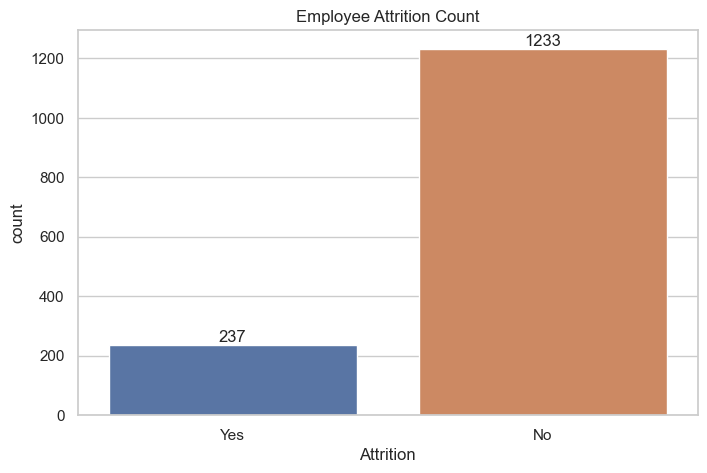

In [23]:
ax = sns.countplot(data=df, x="Attrition", palette=["#4C72B0", "#DD8452"])
ax.set_title("Employee Attrition Count")
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")
plt.show()

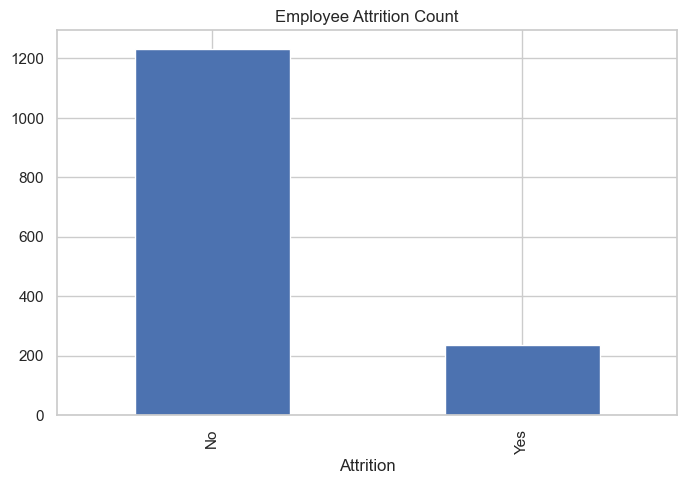

In [24]:
df["Attrition"].value_counts().plot(kind="bar")
plt.title("Employee Attrition Count")
plt.show()

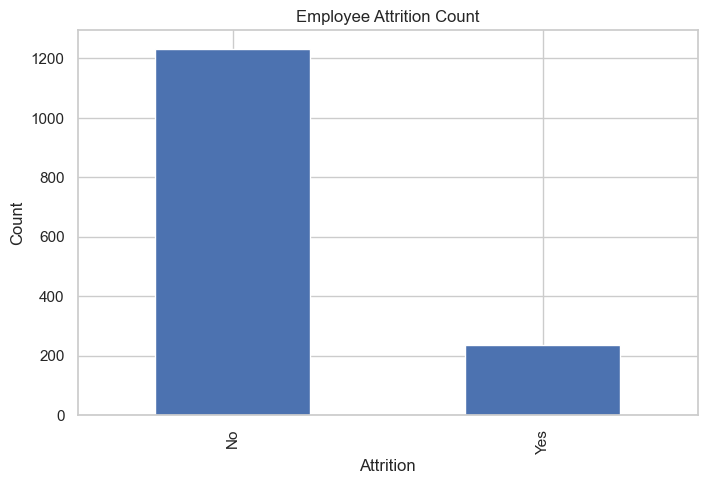

In [25]:
df["Attrition"].value_counts().plot(kind="bar")
plt.title("Employee Attrition Count")
plt.xlabel("Attrition")
plt.ylabel("Count")
plt.show()

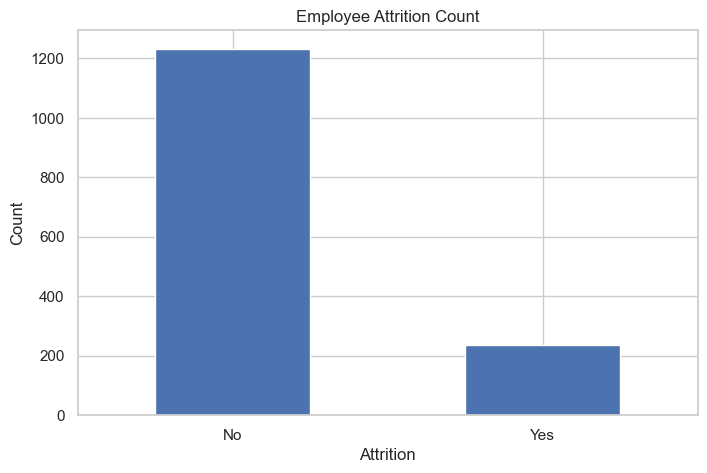

In [26]:
df["Attrition"].value_counts().plot(kind="bar")
plt.title("Employee Attrition Count")
plt.xlabel("Attrition")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

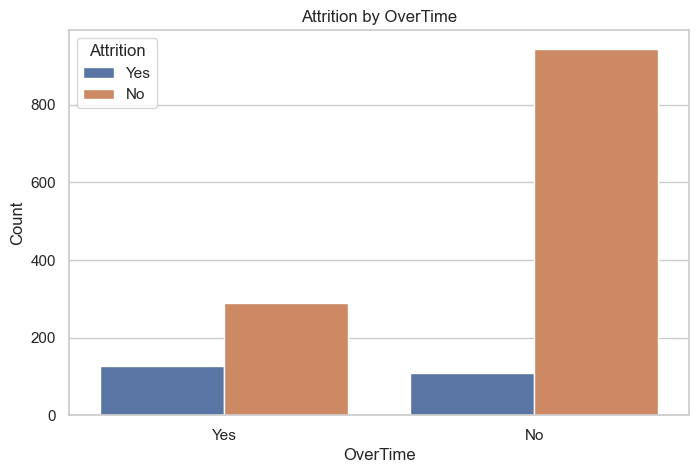

In [27]:
sns.countplot(data=df, x="OverTime", hue="Attrition")
plt.title("Attrition by OverTime")
plt.xlabel("OverTime")
plt.ylabel("Count")
plt.show()

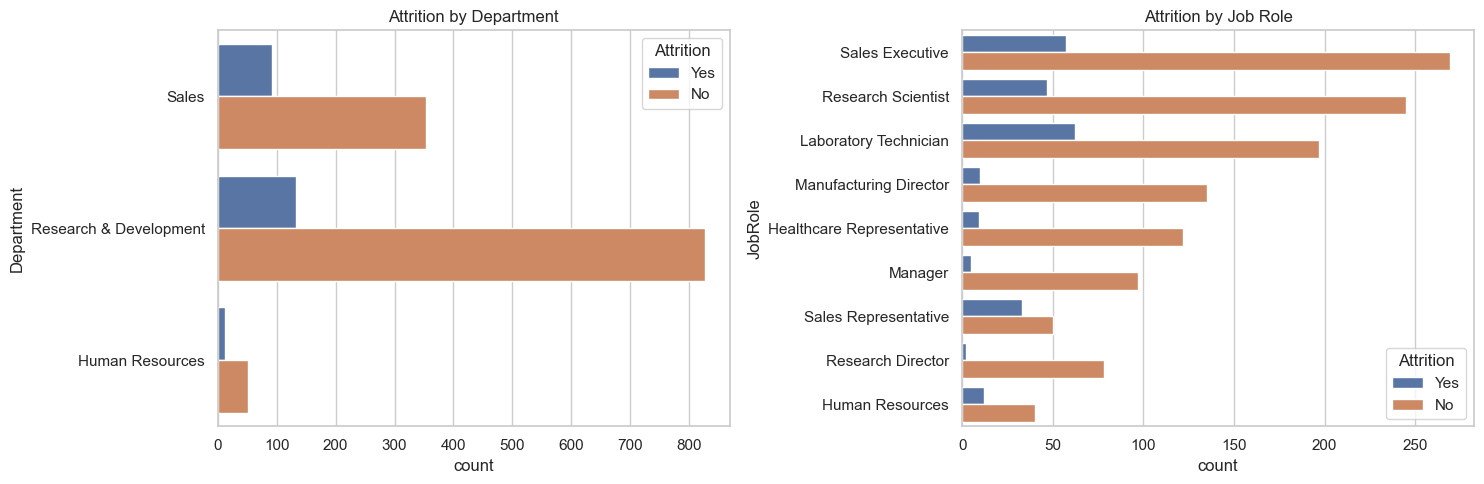

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.countplot(data=df, y="Department", hue="Attrition", ax=axes[0])
axes[0].set_title("Attrition by Department")
sns.countplot(data=df, y="JobRole", hue="Attrition", ax=axes[1])
axes[1].set_title("Attrition by Job Role")
plt.tight_layout()
plt.show()

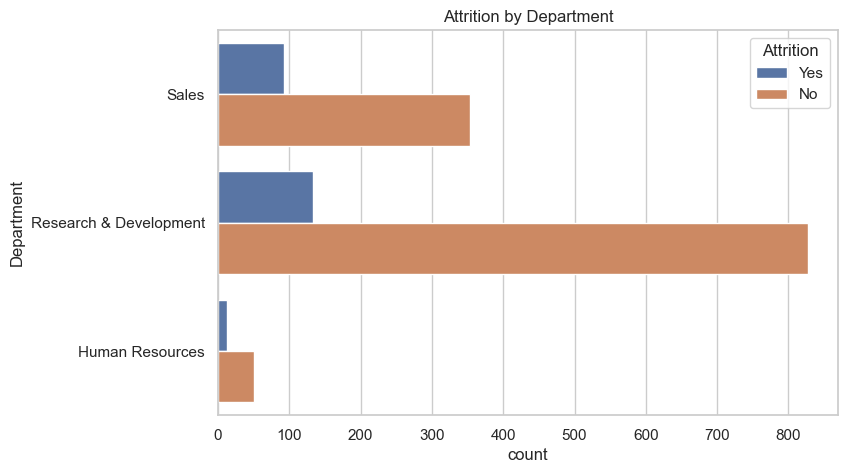

In [29]:
sns.countplot(data=df, y="Department", hue="Attrition")
plt.title("Attrition by Department")
plt.show()

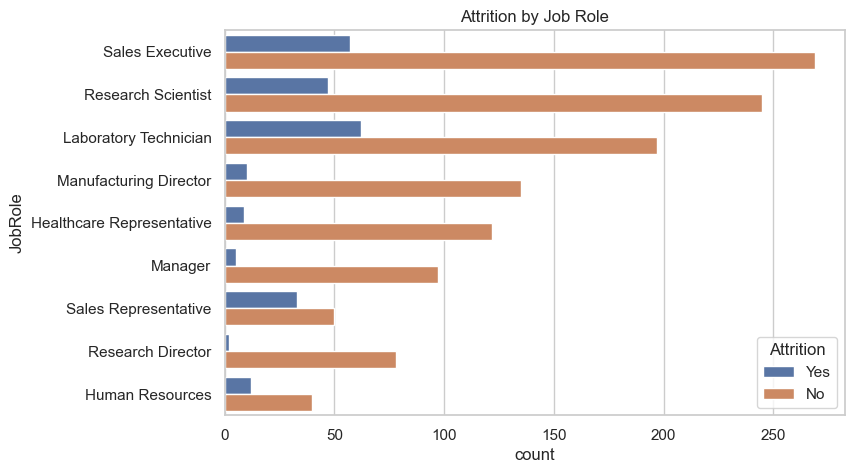

In [30]:
sns.countplot(data=df, y="JobRole", hue="Attrition")
plt.title("Attrition by Job Role")
plt.show()

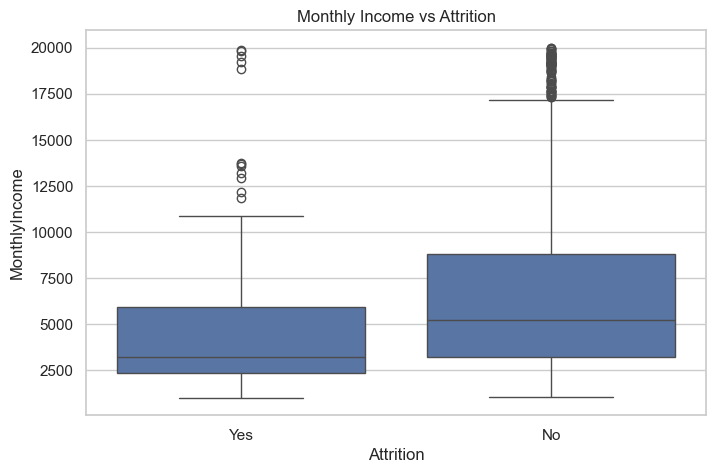

In [31]:
sns.boxplot(data=df, x="Attrition", y="MonthlyIncome")
plt.title("Monthly Income vs Attrition")
plt.show()

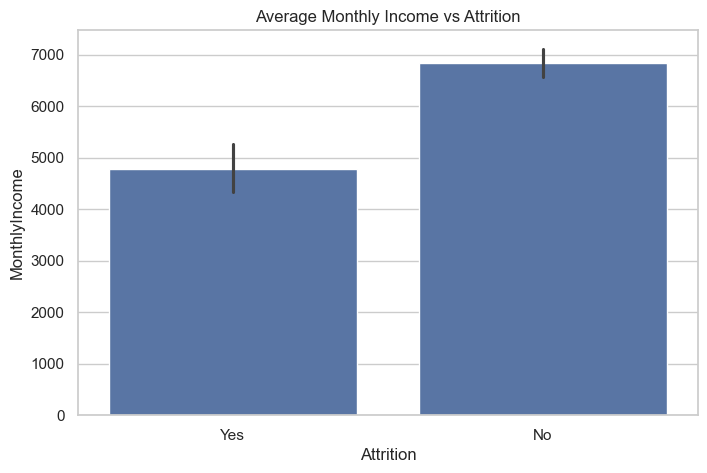

In [32]:
sns.barplot(data=df, x="Attrition", y="MonthlyIncome")
plt.title("Average Monthly Income vs Attrition")
plt.show()

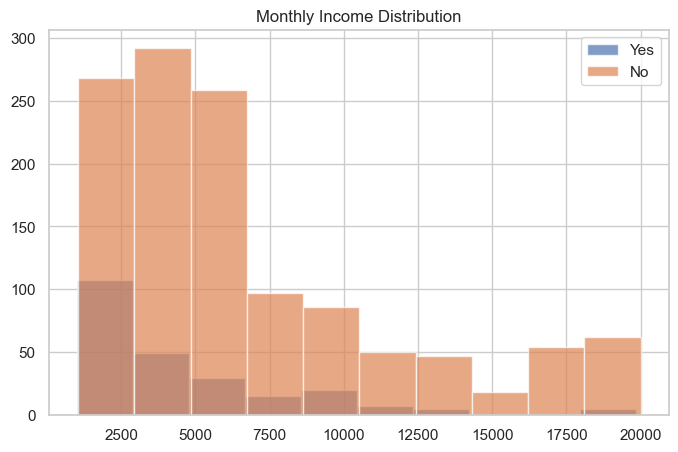

In [33]:
df[df["Attrition"]=="Yes"]["MonthlyIncome"].hist(alpha=0.7, label="Yes")
df[df["Attrition"]=="No"]["MonthlyIncome"].hist(alpha=0.7, label="No")
plt.legend()
plt.title("Monthly Income Distribution")
plt.show()

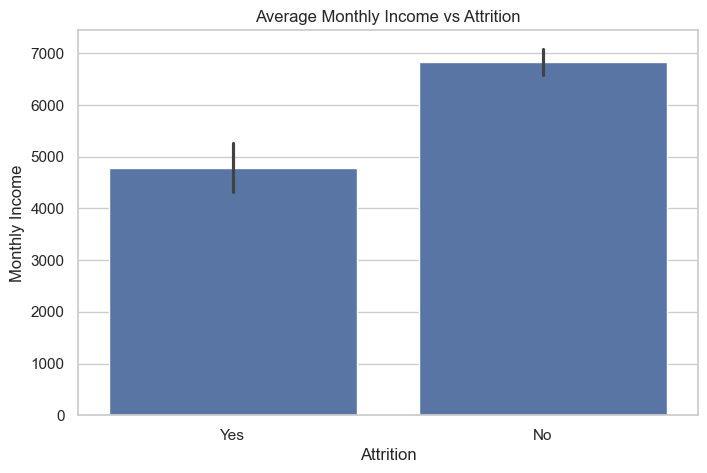

In [34]:
sns.barplot(data=df, x="Attrition", y="MonthlyIncome")
plt.title("Average Monthly Income vs Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.show()

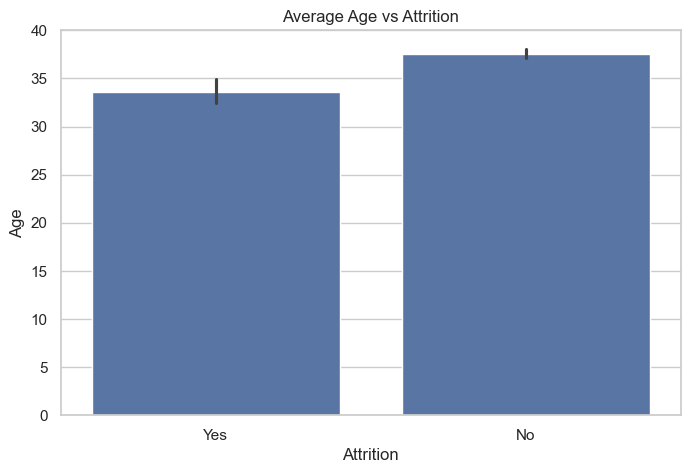

In [35]:
sns.barplot(data=df, x="Attrition", y="Age")
plt.title("Average Age vs Attrition")
plt.xlabel("Attrition")
plt.ylabel("Age")
plt.show()

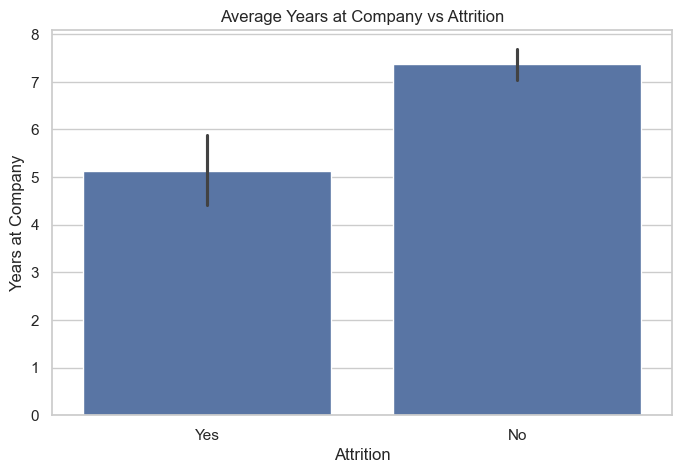

In [36]:
sns.barplot(data=df, x="Attrition", y="YearsAtCompany")
plt.title("Average Years at Company vs Attrition")
plt.xlabel("Attrition")
plt.ylabel("Years at Company")
plt.show()

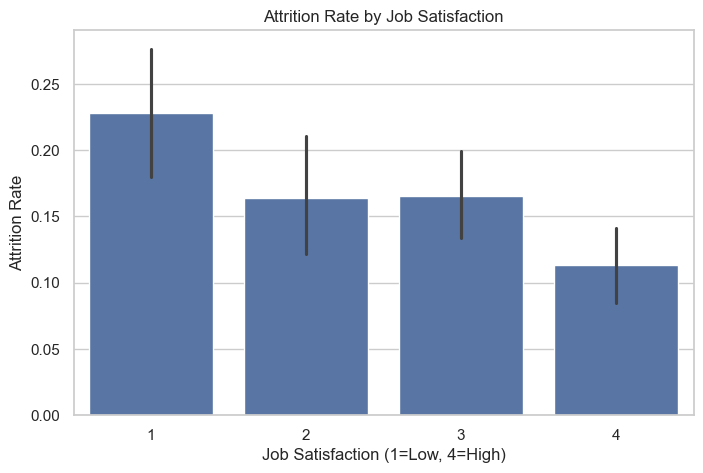

In [37]:
df["Attrition_num"] = df["Attrition"].map({"Yes": 1, "No": 0})

sns.barplot(data=df, x="JobSatisfaction", y="Attrition_num")
plt.title("Attrition Rate by Job Satisfaction")
plt.xlabel("Job Satisfaction (1=Low, 4=High)")
plt.ylabel("Attrition Rate")
plt.show()

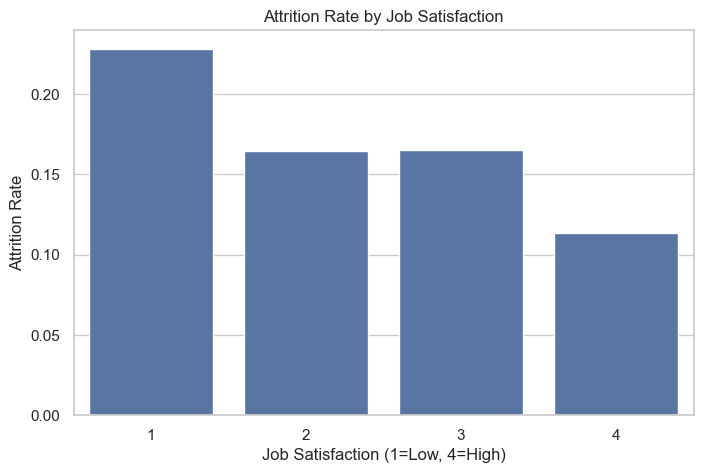

In [38]:
sns.barplot(data=df, x="JobSatisfaction", y="Attrition_num", errorbar=None)
plt.title("Attrition Rate by Job Satisfaction")
plt.xlabel("Job Satisfaction (1=Low, 4=High)")
plt.ylabel("Attrition Rate")
plt.show()

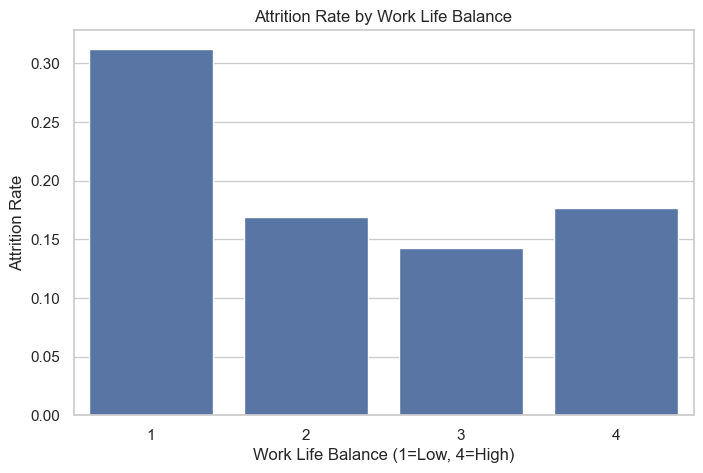

In [39]:
sns.barplot(data=df, x="WorkLifeBalance", y="Attrition_num", errorbar=None)
plt.title("Attrition Rate by Work Life Balance")
plt.xlabel("Work Life Balance (1=Low, 4=High)")
plt.ylabel("Attrition Rate")
plt.show()

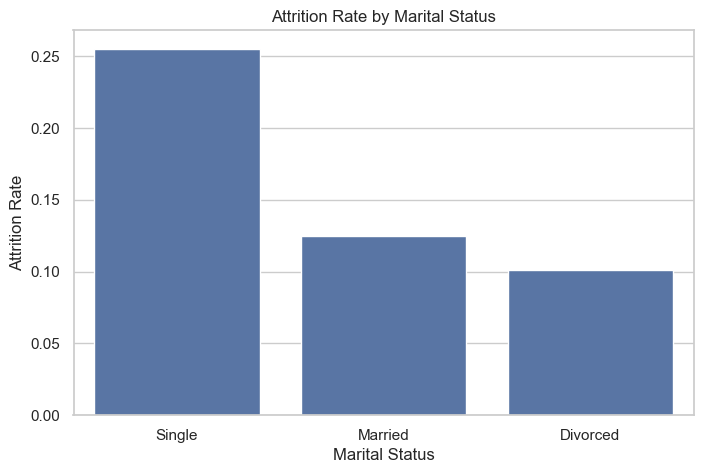

In [40]:
sns.barplot(data=df, x="MaritalStatus", y="Attrition_num", errorbar=None)
plt.title("Attrition Rate by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Attrition Rate")
plt.show()

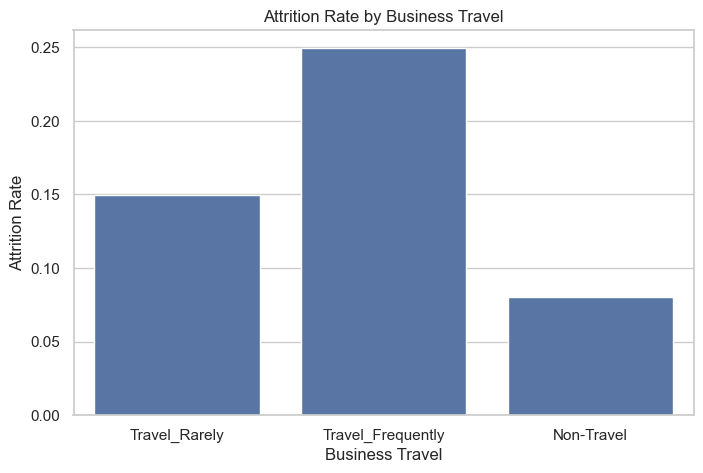

In [41]:
sns.barplot(data=df, x="BusinessTravel", y="Attrition_num", errorbar=None)
plt.title("Attrition Rate by Business Travel")
plt.xlabel("Business Travel")
plt.ylabel("Attrition Rate")
plt.show()

In [42]:
drop_cols = ["EmployeeCount", "StandardHours", "Over18", "EmployeeNumber"]
df_model = df.drop(columns=drop_cols)

df_model["Attrition"] = df_model["Attrition"].map({"No": 0, "Yes": 1})
df_model.shape



(1470, 32)

In [43]:
df_model = df_model.drop(columns=["Attrition_num"])
df_model.shape

(1470, 31)

In [44]:
df_model.shape

(1470, 31)

In [45]:
df_model.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Yes,11,3,1,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,No,23,4,4,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Yes,15,3,2,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Yes,11,3,3,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,No,12,3,4,1,6,3,3,2,2,2,2


In [46]:
y = df_model["Attrition"]
X = df_model.drop(columns="Attrition")

X = pd.get_dummies(X, drop_first=True)
X.shape

(1470, 44)

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data train:", X_train.shape)
print("Data test:", X_test.shape)

Data train: (1176, 44)
Data test: (294, 44)


In [49]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

logreg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
logreg.fit(X_train, y_train)

rf = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42)
rf.fit(X_train, y_train)

print("Model siap dilatih!")

C:\Users\User\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Model siap dilatih!


In [51]:
logreg = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)

In [52]:
from sklearn.metrics import classification_report

y_pred_logreg = logreg.predict(X_test)
y_pred_rf = rf.predict(X_test)

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_logreg))

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))

NotFittedError: This LogisticRegression instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

logreg = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)
logreg.fit(X_train, y_train)

rf = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42)
rf.fit(X_train, y_train)

print("Model siap dilatih!")

C:\Users\User\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Model siap dilatih!


In [54]:
from sklearn.metrics import classification_report

y_pred_logreg = logreg.predict(X_test)
y_pred_rf = rf.predict(X_test)

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_logreg))

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.93      0.77      0.84       255
           1       0.30      0.64      0.41        39

    accuracy                           0.75       294
   macro avg       0.62      0.70      0.62       294
weighted avg       0.85      0.75      0.79       294

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.89      0.97      0.93       255
           1       0.56      0.26      0.35        39

    accuracy                           0.87       294
   macro avg       0.73      0.61      0.64       294
weighted avg       0.85      0.87      0.85       294



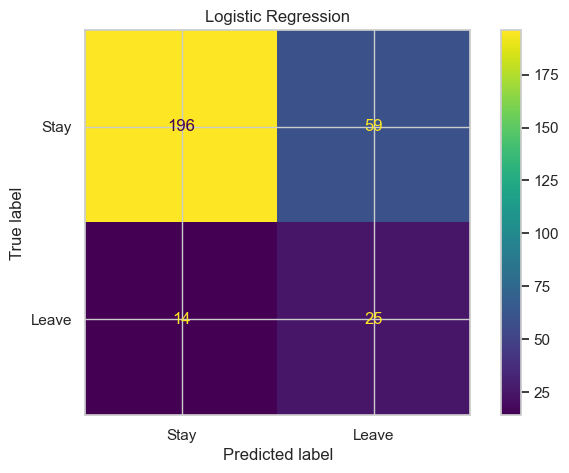

In [55]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_logreg),
                       display_labels=["Stay", "Leave"]).plot()
plt.title("Logistic Regression")
plt.show()

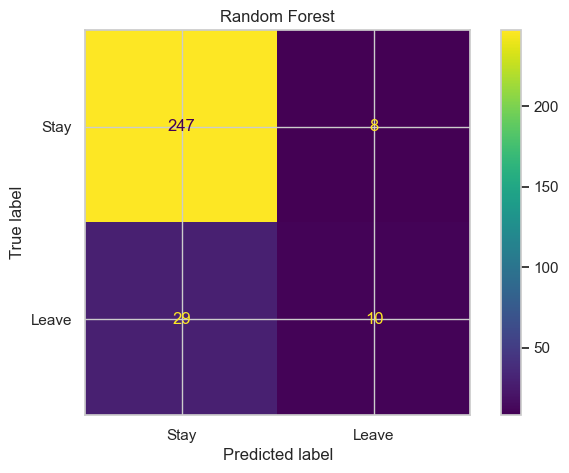

In [56]:
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf),
                       display_labels=["Stay", "Leave"]).plot()
plt.title("Random Forest")
plt.show()

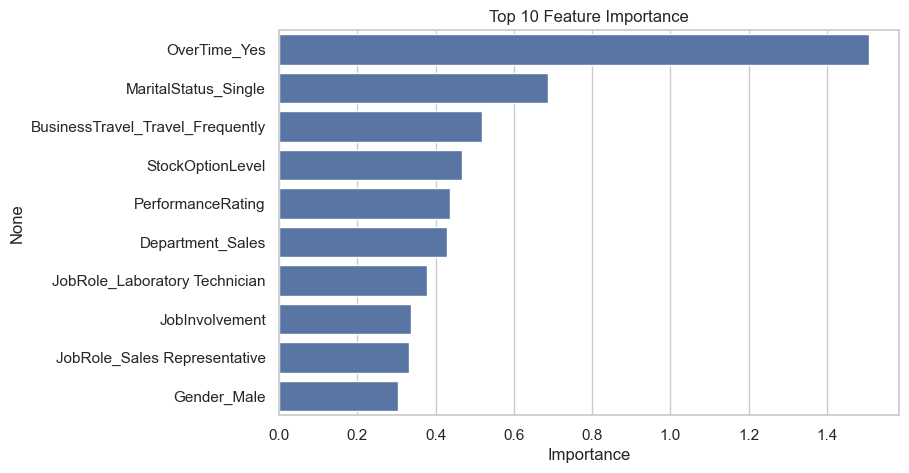

In [57]:
import numpy as np

feature_importance = pd.Series(
    np.abs(logreg.coef_[0]), 
    index=X.columns
).sort_values(ascending=False).head(10)

sns.barplot(x=feature_importance.values, y=feature_importance.index)
plt.title("Top 10 Feature Importance")
plt.xlabel("Importance")
plt.show()

In [58]:
import joblib

joblib.dump(logreg, "hr_attrition_model.pkl")
joblib.dump(list(X.columns), "hr_attrition_features.pkl")
print("Model berjaya disimpan!")

Model berjaya disimpan!
